# Exp4_real MOV




## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.stats import wilcoxon, ttest_rel, rankdata

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 2. Configuration



In [2]:
# All real recordings to analyse
SESSION_FILES = sorted(Path(".").glob("sesion_tesis_full*.csv"))

FIXED_EPS        = 0.12
FIXED_MIN_SAMPS  = 3

ALPHA_MIN = 0.30
ALPHA_MAX = 0.70
TAU       = 1.5
BETA      = 0.0
R_THETA   = 4.0

S_OBJ_M       = 0.40          # representative object width [m]
MIN_RANGE_MM  = 100           # drop unreliable very-near returns
MAX_RANGE_MM  = 8000          # keep finite returns within sensor range

print("Sessions found:")
for f in SESSION_FILES: print("  ", f.name)


Sessions found:
   sesion_tesis_full.csv
   sesion_tesis_full3.csv
   sesion_tesis_full4.csv
   sesion_tesis_full5.csv
   sesion_tesis_full6.csv
   sesion_tesis_full7.csv


## 3. Kernel — Single Source of Truth (identical to Exp6/Exp7)

In [3]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def r0_from_device(s_obj_m, dtheta_deg, min_pts=FIXED_MIN_SAMPS):
    return s_obj_m / (min_pts * np.deg2rad(dtheta_deg))

def alpha_schedule(r_bar_m, r0_m):
    return ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * sigmoid((r0_m - r_bar_m) / TAU)

def prepare_points_euclidean(df):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    return np.column_stack([r * np.cos(th), r * np.sin(th)])

def prepare_points_kernel(df, r_bar_m, r0_m):
    r = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    alpha = alpha_schedule(r_bar_m, r0_m)
    rp = r ** alpha
    thp = th * (1.0 + BETA * max(0.0, r_bar_m - R_THETA))
    return np.column_stack([rp * np.cos(thp), rp * np.sin(thp)]), alpha

def run_dbscan(points):
    return DBSCAN(eps=FIXED_EPS, min_samples=FIXED_MIN_SAMPS).fit_predict(points)

def n_clusters(l): return len(set(l)) - (1 if -1 in l else 0)
def noise_pct(l):  return 100.0 * np.sum(l == -1) / len(l)

def estimate_dtheta(df):
    diffs = []
    for _, g in df.groupby("timestamp"):
        a = np.sort(g["angle_deg"].values); d = np.diff(a); d = d[(d > 0) & (d < 5)]
        diffs.extend(d)
    return float(np.median(diffs)) if diffs else 1.0

def internal_metrics(points_euclid, labels):
    """Silhouette + Davies-Bouldin on the REAL coordinates (fair across methods).
    Computed on non-noise points; needs >= 2 clusters."""
    mask = labels != -1
    if mask.sum() < 3:
        return np.nan, np.nan
    pts, lab = points_euclid[mask], labels[mask]
    if len(set(lab)) < 2:
        return np.nan, np.nan
    try:
        return silhouette_score(pts, lab), davies_bouldin_score(pts, lab)
    except Exception:
        return np.nan, np.nan

print("Kernel + metric helpers ready.")


Kernel + metric helpers ready.


## 4. Process Every Scan (baseline vs. kernel)

In [4]:
rows = []
for f in SESSION_FILES:
    sess = pd.read_csv(f)
    sess = sess[np.isfinite(sess["distance_mm"]) & np.isfinite(sess["angle_deg"])]
    sess = sess[(sess["distance_mm"] >= MIN_RANGE_MM) & (sess["distance_mm"] <= MAX_RANGE_MM)]
    dtheta = estimate_dtheta(sess)
    r0 = r0_from_device(S_OBJ_M, dtheta)

    for ts, df in sess.groupby("timestamp"):
        if len(df) < FIXED_MIN_SAMPS:
            continue
        r_bar = df["distance_mm"].median() / 1000.0
        pts_e = prepare_points_euclidean(df)
        lab_b = run_dbscan(pts_e)
        pts_k, alpha = prepare_points_kernel(df, r_bar, r0)
        lab_k = run_dbscan(pts_k)

        # internal metrics scored in the SAME (real, euclidean) space for both
        sil_b, db_b = internal_metrics(pts_e, lab_b)
        sil_k, db_k = internal_metrics(pts_e, lab_k)

        rows.append({
            "session": f.name, "timestamp": ts, "n_points": len(df),
            "dtheta_deg": dtheta, "r_bar_m": r_bar, "alpha": alpha,
            "clusters_baseline": n_clusters(lab_b), "clusters_kernel": n_clusters(lab_k),
            "noise_baseline": noise_pct(lab_b), "noise_kernel": noise_pct(lab_k),
            "silhouette_baseline": sil_b, "silhouette_kernel": sil_k,
            "db_baseline": db_b, "db_kernel": db_k,
        })

results_df = pd.DataFrame(rows)
print(f"Processed {len(results_df)} scans from {results_df['session'].nunique()} sessions")
print(f"Median dtheta {results_df['dtheta_deg'].median():.2f} deg | "
      f"r_bar {results_df['r_bar_m'].min():.2f}-{results_df['r_bar_m'].max():.2f} m | "
      f"alpha {results_df['alpha'].min():.3f}-{results_df['alpha'].max():.3f}")
results_df.head()


Processed 1508 scans from 6 sessions
Median dtheta 1.34 deg | r_bar 0.12-1.22 m | alpha 0.681-0.690


,session,timestamp,n_points,dtheta_deg,r_bar_m,alpha,clusters_baseline,clusters_kernel,noise_baseline,noise_kernel,silhouette_baseline,silhouette_kernel,db_baseline,db_kernel
0,sesion_tesis_full.csv,1.778622e+09,106,1.328125,0.498375,0.688303,4,4,6.603774,5.660377,0.707785,0.698612,0.379196,0.384707
1,sesion_tesis_full.csv,1.778622e+09,122,1.328125,0.495250,0.688327,4,4,5.737705,5.737705,0.712416,0.712416,0.391482,0.391482
2,sesion_tesis_full.csv,1.778622e+09,121,1.328125,0.493500,0.688340,5,5,0.826446,0.826446,0.711677,0.711677,0.343825,0.343825
3,sesion_tesis_full.csv,1.778622e+09,126,1.328125,0.494500,0.688332,5,5,2.380952,2.380952,0.707983,0.707983,0.366009,0.366009
4,sesion_tesis_full.csv,1.778622e+09,122,1.328125,0.494125,0.688335,4,5,3.278689,0.819672,0.710000,0.714578,0.405810,0.358422


## 5. Statistical Analysis (paired across scans)



In [5]:
def rank_biserial(a, b):
    d = np.asarray(a) - np.asarray(b); d = d[d != 0]
    if len(d) == 0: return 0.0
    r = rankdata(np.abs(d)); return (r[d > 0].sum() - r[d < 0].sum()) / r.sum()

def paired_report(col_a, col_b, label):
    a = results_df[col_a].values; b = results_df[col_b].values
    m = np.isfinite(a) & np.isfinite(b); a, b = a[m], b[m]
    rec = {"metric": label, "n_scans": len(a),
           f"{col_a} mean": a.mean(), f"{col_b} mean": b.mean()}
    try: t, pt = ttest_rel(a, b); rec["t"] = t; rec["p_ttest"] = pt
    except Exception: rec["t"] = np.nan; rec["p_ttest"] = np.nan
    try: _, pw = wilcoxon(a, b); rec["p_wilcoxon"] = pw
    except Exception: rec["p_wilcoxon"] = np.nan
    rec["rank_biserial"] = rank_biserial(a, b)
    return rec

summary = pd.DataFrame([
    paired_report("noise_baseline",      "noise_kernel",      "Noise % (lower=better)"),
    paired_report("silhouette_kernel",   "silhouette_baseline","Silhouette (higher=better)"),
    paired_report("db_baseline",         "db_kernel",         "Davies-Bouldin (lower=better)"),
])
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))


                       metric  n_scans  noise_baseline mean  noise_kernel mean      t    p_ttest  p_wilcoxon  rank_biserial  silhouette_kernel mean  silhouette_baseline mean  db_baseline mean  db_kernel mean
       Noise % (lower=better)     1508                 5.09              3.788  30.16 9.478e-157  3.898e-140         0.9697                     NaN                       NaN               NaN             NaN
   Silhouette (higher=better)     1505                  NaN                NaN  2.554    0.01074      0.2855       -0.03782                  0.6729                    0.6711               NaN             NaN
Davies-Bouldin (lower=better)     1505                  NaN                NaN 0.3323     0.7397     0.04418       -0.07126                     NaN                       NaN            0.3323          0.3321


## 6. Visualisation

C:\Users\herna\AppData\Local\Temp\ipykernel_35732\1335924947.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([results_df["noise_baseline"], results_df["noise_kernel"]],
C:\Users\herna\AppData\Local\Temp\ipykernel_35732\1335924947.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([s["silhouette_baseline"], s["silhouette_kernel"]],
C:\Users\herna\AppData\Local\Temp\ipykernel_35732\1335924947.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([d["db_baseline"], d["db_kernel"]],


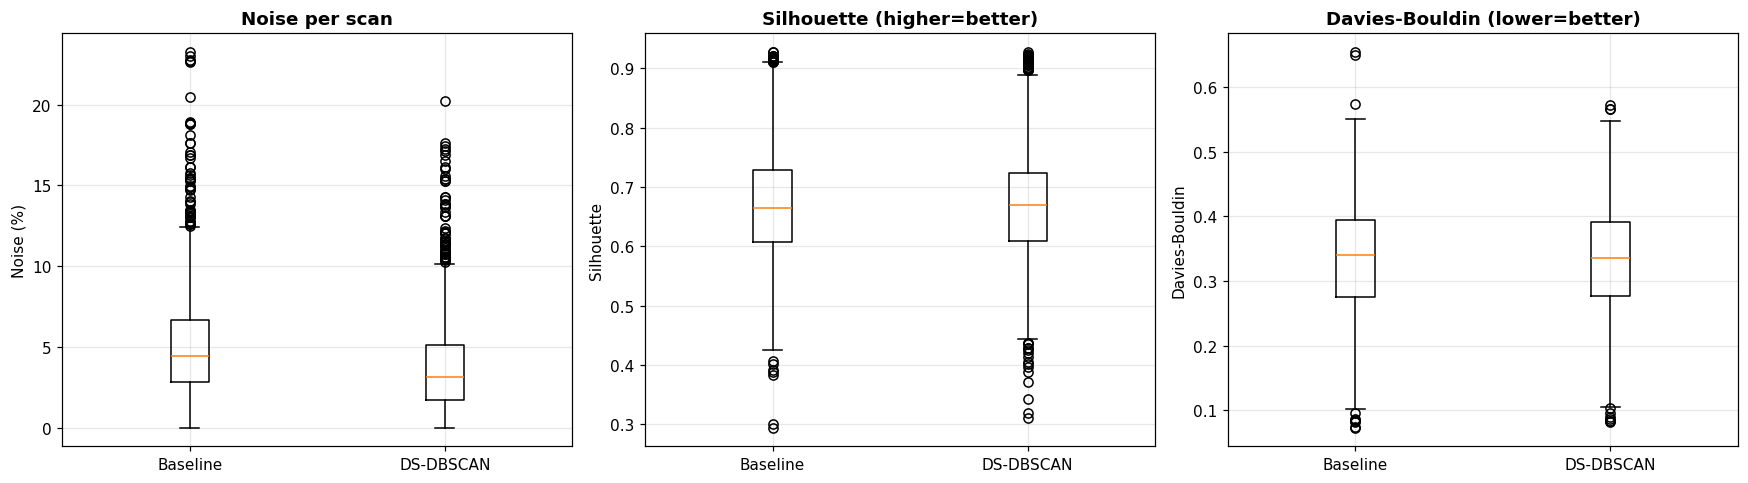

Saved: fig_exp8_real.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].boxplot([results_df["noise_baseline"], results_df["noise_kernel"]],
                labels=["Baseline", "DS-DBSCAN"])
axes[0].set_ylabel("Noise (%)"); axes[0].set_title("Noise per scan", fontweight="bold")

s = results_df[["silhouette_baseline", "silhouette_kernel"]].dropna()
axes[1].boxplot([s["silhouette_baseline"], s["silhouette_kernel"]],
                labels=["Baseline", "DS-DBSCAN"])
axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette (higher=better)", fontweight="bold")

d = results_df[["db_baseline", "db_kernel"]].dropna()
axes[2].boxplot([d["db_baseline"], d["db_kernel"]],
                labels=["Baseline", "DS-DBSCAN"])
axes[2].set_ylabel("Davies-Bouldin"); axes[2].set_title("Davies-Bouldin (lower=better)", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_exp8_real.png", bbox_inches="tight")
plt.show()
print("Saved: fig_exp8_real.png")


## 7. Export

In [7]:
results_df.to_csv("exp8_real_results.csv", index=False)
summary.to_csv("exp8_real_stats.csv", index=False)
print("Saved: exp8_real_results.csv, exp8_real_stats.csv\n")
print(f"Noise:      baseline {results_df['noise_baseline'].mean():.1f}%"
      f" -> kernel {results_df['noise_kernel'].mean():.1f}%")
sb, sk = results_df['silhouette_baseline'].mean(), results_df['silhouette_kernel'].mean()
print(f"Silhouette: baseline {sb:.3f} -> kernel {sk:.3f}")
print(f"Davies-Bouldin: baseline {results_df['db_baseline'].mean():.3f}"
      f" -> kernel {results_df['db_kernel'].mean():.3f}")


Saved: exp8_real_results.csv, exp8_real_stats.csv

Noise:      baseline 5.1% -> kernel 3.8%
Silhouette: baseline 0.671 -> kernel 0.673
Davies-Bouldin: baseline 0.332 -> kernel 0.332


## 8. Notes — Real Data vs. Simulation




Found files: ['mov1.csv', 'mov2.csv', 'mov3.csv', 'mov4.csv', 'mov5.csv', 'mov6.csv', 'mov7.csv']
465 frames across 7 runs
Frame 66 (mov2, ts=1780761077.601426) | 162 pts | Δθ≈1.36° | r̄=0.86 m | α=0.499
Baseline:  11 clusters, 6.8% noise
DS-DBSCAN: 10 clusters, 6.2% noise


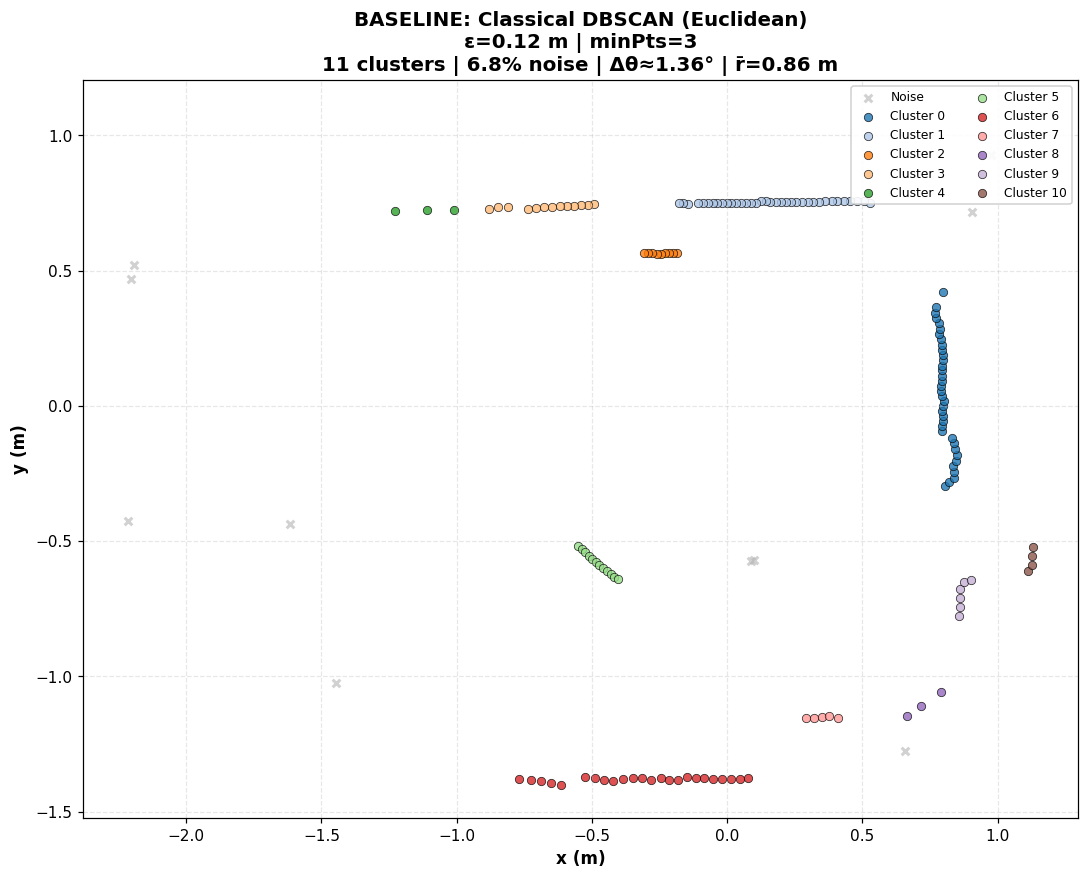

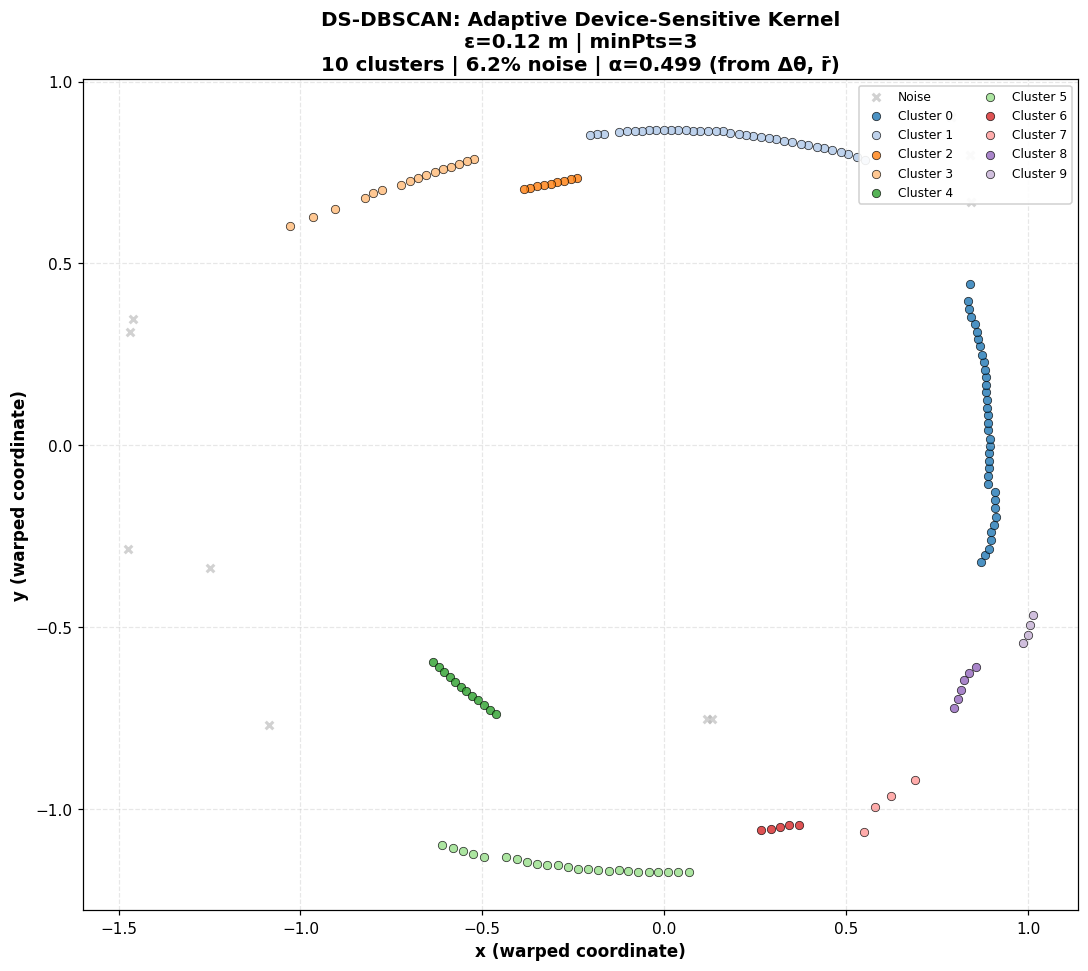

In [12]:
import numpy as np, pandas as pd, glob, os
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# ---------- constants (from Cell 2) ----------
FIXED_EPS, MIN_PTS = 0.12, 3
ALPHA_MIN, ALPHA_MAX = 0.30, 0.70
TAU = 1.5
S_OBJ_M = 0.06
RANGE_MIN, RANGE_MAX = 0.15, 12.0

# ---------- helpers (from Cell 4) ----------
def sigmoid(z): return 1.0/(1.0+np.exp(-z))
def r0_from_device(s_obj_m, dtheta_deg, min_pts=MIN_PTS):
    return s_obj_m / (min_pts * np.deg2rad(dtheta_deg))
def alpha_schedule(r_bar_m, r0_m):
    return ALPHA_MIN + (ALPHA_MAX-ALPHA_MIN)*sigmoid((r0_m-r_bar_m)/TAU)
def dtheta_of(theta_deg):
    s=np.sort(theta_deg); d=np.diff(s); d=d[d>0]; return float(np.median(d)) if len(d) else 1.34
def points_euclidean(r_m, th):
    return np.column_stack([r_m*np.cos(th), r_m*np.sin(th)])
def points_kernel(r_m, th, theta_deg, s_obj_m):
    r_bar=np.median(r_m)
    alpha=alpha_schedule(r_bar, r0_from_device(s_obj_m, dtheta_of(theta_deg)))
    rp=r_m**alpha
    return np.column_stack([rp*np.cos(th), rp*np.sin(th)]), alpha
def run_dbscan(pts): return DBSCAN(eps=FIXED_EPS, min_samples=MIN_PTS).fit_predict(pts)
def n_clusters(l):   return len(set(l)) - (1 if -1 in l else 0)
def noise_pct(l):    return 100.0*np.sum(l==-1)/len(l)

# ---------- build frames (from Cell 6) ----------
FILES = sorted(glob.glob("mov[1-7].csv"))
print("Found files:", FILES)
frames = []
for f in FILES:
    d = pd.read_csv(f)
    d = d[np.isfinite(d["distance_mm"]) & np.isfinite(d["angle_deg"])]
    run = os.path.splitext(os.path.basename(f))[0]
    for ts, g in d.groupby("timestamp"):
        r  = g["distance_mm"].values / 1000.0
        th = np.deg2rad(g["angle_deg"].values)
        m  = (r >= RANGE_MIN) & (r <= RANGE_MAX)
        if m.sum() < MIN_PTS: continue
        frames.append(dict(run=run, ts=ts, r=r[m], th=th[m],
                           theta_deg=g["angle_deg"].values[m]))
print(f"{len(frames)} frames across {len(FILES)} runs")

# ---------- colormap ----------
def create_enhanced_colormap(n_colors=25):
    base = list(plt.cm.tab20(np.linspace(0, 1, 20)))
    if n_colors > 20:
        base += list(plt.cm.hsv(np.linspace(0, 0.9, n_colors - 20)))
    return base, np.array([0.7, 0.7, 0.7, 1.0])

# ===== CHOOSE THE FRAME =====
FRAME_INDEX = len(frames) // 7
# ============================
fr = frames[FRAME_INDEX]
r, th, theta_deg = fr["r"], fr["th"], fr["theta_deg"]
r_bar = np.median(r)

pts_b = points_euclidean(r, th); lab_b = run_dbscan(pts_b)
pts_k, alpha = points_kernel(r, th, theta_deg, S_OBJ_M); lab_k = run_dbscan(pts_k)

nb_, nk_     = n_clusters(lab_b), n_clusters(lab_k)
noi_b, noi_k = noise_pct(lab_b), noise_pct(lab_k)
dtheta = dtheta_of(theta_deg)
colors, noise_color = create_enhanced_colormap(max(nb_, nk_) + 5)

print(f"Frame {FRAME_INDEX} ({fr['run']}, ts={fr['ts']}) | {len(r)} pts | "
      f"Δθ≈{dtheta:.2f}° | r̄={r_bar:.2f} m | α={alpha:.3f}")
print(f"Baseline:  {nb_} clusters, {noi_b:.1f}% noise")
print(f"DS-DBSCAN: {nk_} clusters, {noi_k:.1f}% noise")

def plot_one(pts, lab, title, xlab, ylab, fname):
    fig, ax = plt.subplots(figsize=(10, 9))
    nm = lab == -1
    if nm.sum() > 0:
        ax.scatter(pts[nm, 0], pts[nm, 1], c=[noise_color], s=25, marker='x',
                   linewidths=2, label='Noise', alpha=0.6)
    for cid in sorted(set(lab)):
        if cid == -1: continue
        mm = lab == cid
        ax.scatter(pts[mm, 0], pts[mm, 1], c=[colors[cid % len(colors)]], s=30,
                   label=f'Cluster {cid}', alpha=0.8, edgecolors='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel(xlab, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylab, fontsize=11, fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()

plot_one(pts_b, lab_b,
    f'BASELINE: Classical DBSCAN (Euclidean)\nε={FIXED_EPS} m | minPts={MIN_PTS}\n'
    f'{nb_} clusters | {noi_b:.1f}% noise | Δθ≈{dtheta:.2f}° | r̄={r_bar:.2f} m',
    'x (m)', 'y (m)', 'exp4_baseline.png')

plot_one(pts_k, lab_k,
    f'DS-DBSCAN: Adaptive Device-Sensitive Kernel\nε={FIXED_EPS} m | minPts={MIN_PTS}\n'
    f'{nk_} clusters | {noi_k:.1f}% noise | α={alpha:.3f} (from Δθ, r̄)',
    'x (warped coordinate)', 'y (warped coordinate)', 'exp4_kernel.png')